# Using the BPSec pipeline

This guide shows how to prepare a scenario, compute routes, inspect security
plans, optimize key allocation, and plot the results. It uses a small network
so that every example can run from a fresh kernel in a few seconds.

You need basic Python knowledge and Python 3.11 or later. From the repository
root, install the dependencies in the same environment as your notebook kernel:

```bash
python -m pip install -r requirements-notebooks.txt
```

Routing, annotation, security planning, and activation planning do not require
a Gurobi license. The optimization examples require an accessible Gurobi license.
Open this notebook from the repository and run its cells in order.

1. Create or load a scenario.
2. Run the pipeline and inspect its catalogs.
3. Reuse stages and configure security policies.
4. Optimize and visualize key allocation.
5. Handle unreachable pairs and compose a custom optimization.
6. Run the existing scenario notebooks and validate your changes.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "pipelines" / "simulation.py").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Open this notebook from within the BPSec Keys repository.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from modules.domain import ContactSnapshot, PlanRef, Scenario
from modules.network.topology import Topology
from pipelines.routing import CGRYenRouting, RoutingBatchRequest
from pipelines.simulation import (
    RouteAnnotationStage, RoutingStage, SecurityPlanningStage, SimulationPipeline,
)

## 1. Create a scenario

`Scenario` combines a topology, immutable contacts, and the ordered node pairs
to evaluate. Here, nodes 1–2 belong to network 10 and nodes 3–4 to network 20.
The two paths from 1 to 4 are `1 → 2 → 4` and `1 → 3 → 4`; reverse contacts
also exist.

Times and propagation delays are in seconds. Using bytes/s for `rate` makes
route volumes bytes. `pairs` defines the connectivity denominator, including
pairs with no route. Omitting it requests every ordered pair of distinct nodes;
an explicit empty tuple requests no pairs.

In [2]:
topology = Topology(
    node_to_network={1: 10, 2: 10, 3: 20, 4: 20},
    network_to_nodes={10: frozenset({1, 2}), 20: frozenset({3, 4})},
)
links = ((1, 2), (2, 4), (1, 3), (3, 4))
contacts = tuple(
    ContactSnapshot(frm=source, to=destination, start=0, end=100, rate=1000, owlt=1)
    for left, right in links
    for source, destination in ((left, right), (right, left))
)
scenario = Scenario(topology, contacts, pairs=((1, 4), (4, 1)))
print(f"{len(topology)} nodes, {len(contacts)} contacts, {len(scenario.pairs)} requested pairs")

4 nodes, 8 contacts, 2 requested pairs


### Load repository data instead

`Scenario.from_files` accepts the same JSON files used by the scenario notebooks.
The contact-plan fields are `start`, `end`, `from`, `to`, `rate`, and `owlt`.
Topology JSON contains a `networks` list with an `id` and `nodes` for each entry.
This cell only loads Four Planes; subsequent examples keep using the small
in-memory scenario.

In [3]:
four_planes_scenario = Scenario.from_files(
    topology_path=REPO_ROOT / "scenarios/wisee_four_planes_polar/topology.json",
    contact_plan_path=REPO_ROOT / "scenarios/wisee_four_planes_polar/contact_plan_2.json",
)
print(
    f"Four Planes: {len(four_planes_scenario.topology)} nodes, "
    f"{len(four_planes_scenario.contacts)} contacts, "
    f"{len(four_planes_scenario.pairs)} ordered pairs"
)

Four Planes: 20 nodes, 64 contacts, 380 ordered pairs


### Import an ION contact plan

Use `convert_ion_contact_plan(source, destination)` for an ION file, or
`parse_ion_contact_plan(text)` for text already in memory. The source is preserved.
The following miniature example needs no external files.

The converter preserves contact direction and numeric rates. It obtains `owlt`
from `a range` entries and splits contacts when their delay changes. Missing
range coverage raises an error unless you explicitly supply `default_owlt`;
using that fallback emits a warning. Times, rates, and delays must be integers.
Keep the original file if you need its absolute epoch: the JSON contains relative
seconds. The converter does not rescale exported rates or create a topology.

Supported ION input includes `a contact`, `a range`, comments, and an initial
`@` epoch reference. Other administration commands are rejected.

In [4]:
from modules.network.ion_contact_plan import parse_ion_contact_plan

ion_records = parse_ion_contact_plan(
    "a contact +0 +100 1 2 1000\n"
    "a range +0 +100 1 2 1\n"
)
ion_contacts = tuple(
    ContactSnapshot(
        frm=record["from"], to=record["to"], start=record["start"],
        end=record["end"], rate=record["rate"], owlt=record["owlt"],
    )
    for record in ion_records
)
ion_scenario = Scenario(topology, ion_contacts, pairs=((1, 2),))
display(pd.DataFrame(ion_records))

,start,end,from,to,rate,owlt
0,0,100,1,2,1000,1


## 2. Run the pipeline

`SimulationPipeline` coordinates routing, annotation, and security planning.
By default, security planning builds all four families: hop-by-hop (HBH),
end-to-end (E2E), edge-by-edge (EbE), and edge-to-edge (EtE).

`CGRYenRouting(max_routes=2)` chooses the routing strategy and its default limit.
An explicit positive `RoutingBatchRequest.num_routes` overrides that limit;
the stage applies the request limit to every routing adapter. `curr_time` is
the routing query's start time.

In [5]:
request = RoutingBatchRequest(scenario, curr_time=0)
pipeline = SimulationPipeline(routing=RoutingStage(CGRYenRouting(max_routes=2)))
result = pipeline.run(request)

route_table = pd.DataFrame([
    {
        "route": str(ref),
        "node_path": result.annotations.by_route[ref].node_path,
        "delivery_time": candidate.best_delivery_time,
        "volume": candidate.volume,
        "boundary_crossings": len(result.annotations.by_route[ref].boundary_crossings),
    }
    for ref, candidate in result.routes.by_id.items()
])
display(route_table)

,route,node_path,delivery_time,volume,boundary_crossings
0,1->4:route-1,"(1, 2, 4)",2,99000.0,1
1,1->4:route-2,"(1, 3, 4)",2,99000.0,1
2,4->1:route-1,"(4, 2, 1)",2,99000.0,1
3,4->1:route-2,"(4, 3, 1)",2,99000.0,1


### Navigate catalogs by reference

| Catalog | Lookup | Shared context |
| --- | --- | --- |
| `result.routes` | `by_id[RouteRef]`, `routes_by_pair[pair]` | `.scenario` |
| `result.annotations` | `by_route[RouteRef]` | `.routes` |
| `result.protection` | `by_plan[PlanRef]`, `.policies` | `.annotations` |

`routes_by_pair[pair]` contains route references; an empty tuple means no
candidates. A `RouteRef` is local to its catalog, and a `PlanRef` adds a policy
ID. Use these objects for joins rather than matching list positions or parsing
their display strings. Catalog mappings are read-only and retain the previous
stage's data without copying its entire contents.

In [6]:
route_ref = result.routes.routes_by_pair[(1, 4)][0]
candidate = result.routes.by_id[route_ref]
annotation = result.annotations.by_route[route_ref]
plan = result.protection.by_plan[PlanRef(route_ref, "EDGE_TO_EDGE")]

operation_table = pd.DataFrame([
    {
        "operation": operation.ref.local_id,
        "service": operation.service.name,
        "source_node": operation.source_node,
        "acceptor_node": operation.acceptor_node,
        "hop_indexes": operation.target_hop_indexes,
        "key_type": operation.required_key_type.name,
    }
    for operation in plan.operations
])
print(f"Route {route_ref}: {annotation.node_path}")
display(operation_table)
display(pd.DataFrame([
    {"node": node, "required_keys": len(scopes), "scopes": tuple(map(str, scopes))}
    for node, scopes in plan.required_keys_by_node().items()
]))

Route 1->4:route-1: (1, 2, 4)


,operation,service,source_node,acceptor_node,hop_indexes,key_type
0,segment:0-0,BCB,1,2,"(0,)",NODE_TO_GROUP
1,transit,BCB,2,4,"(1,)",GROUP_TO_GROUP


,node,required_keys,scopes
0,1,1,"(NODE_TO_GROUP(1->10),)"
1,2,2,"(NODE_TO_GROUP(1->10), GROUP_TO_GROUP(10->20))"
2,4,1,"(GROUP_TO_GROUP(10->20),)"


`OperationRef` connects each operation to its plan. Both `node_requirements`
and `key_requirements` refer to operations through `operation_ref`.

Global key scopes and node deliveries are different counts. A shared key is
counted once globally but once at every node that needs it. A group key is
delivered to participating security sources and acceptors, rather than every
member of the group. Merely forwarding a route does not imply key delivery.

## 3. Reuse stages and configure policies

You can run stages separately and retain their catalogs. For example, changing
security policies only requires rebuilding protection from existing annotations.

| Replaceable stage | Contract | Default implementation |
| --- | --- | --- |
| `RoutePlanner` | `compute(RoutingBatchRequest) → RouteCatalog` | `RoutingStage` |
| `RouteAnnotator` | `annotate(RouteCatalog) → AnnotationCatalog` | `RouteAnnotationStage` |
| `ProtectionPlanner` | `build(AnnotationCatalog) → ProtectionCatalog` | `SecurityPlanningStage` |

Pass replacements as `SimulationPipeline(routing=..., annotation=..., security=...)`.
These are structural protocols: a custom stage needs the corresponding method,
not inheritance from the default class. Its output must preserve the scenario,
references, and catalog lineage. For an internal routing strategy, implement
`RoutingAlgorithm.compute_routes`; built-in alternatives include
`CGRAnchorRouting`, `CGREndedRouting`, and `CGRDepletedRouting`.

A configured policy has an ID independent of its `SecurityModelType` family.
The example below reuses the E2E implementation with two security services.
It plans operations and key requirements; it does not perform encryption or
integrity verification on actual bundles.

In [7]:
from modules.security.models import SecurityService
from modules.security.planning import ConfiguredSecurityPolicy, EndToEndSecurityModel

class IntegrityEndToEnd(EndToEndSecurityModel):
    """Reuse end-to-end planning with the BIB security service."""

    service = SecurityService.BIB

custom_security = SecurityPlanningStage((
    ConfiguredSecurityPolicy("e2e-confidentiality", EndToEndSecurityModel()),
    ConfiguredSecurityPolicy("e2e-integrity", IntegrityEndToEnd()),
))
custom_protection = custom_security.build(result.annotations)

display(pd.DataFrame([
    {
        "policy_id": policy_id,
        "family": family.name,
        "service": custom_protection.by_plan[PlanRef(route_ref, policy_id)].operations[0].service.name,
    }
    for policy_id, family in custom_protection.policies.items()
]))

,policy_id,family,service
0,e2e-confidentiality,END_TO_END,BCB
1,e2e-integrity,END_TO_END,BIB


Policy IDs must be unique within a catalog. To implement different protection
semantics, implement `SecurityModel.build_plan(annotated_route, *, policy_id)`;
`BaseSecurityModel` provides shared operation and requirement construction.
Do not combine policies' solutions as if they were a single optimization:
the examples below optimize one configured policy at a time.

## 4. Prepare and solve an activation problem

`ActivationPlanner` turns a protection catalog into a solver-independent
`ActivationProblem`. It contains requirements per route, global scopes,
recipient nodes, and inverse indexes (`routes_by_key`, `routes_by_node_key`).

Symmetric normalization merges reversed node-to-node and group-to-group key
scopes. Node-to-group scopes remain directional. The original plans are unchanged.

In [8]:
from pipelines.activation import ActivationPlanner

planner = ActivationPlanner()
problem = planner.build(result.protection, policy_id="EDGE_TO_EDGE")
symmetric_problem = planner.build(
    result.protection, policy_id="EDGE_TO_EDGE", symmetric_keys=True,
)
display(pd.DataFrame([
    {
        "key_mode": label,
        "requested_pairs": len(item.pairs),
        "candidate_routes": len(item.requirements),
        "global_key_scopes": len(item.key_scopes),
    }
    for label, item in (("directional", problem), ("symmetric", symmetric_problem))
]))

,key_mode,requested_pairs,candidate_routes,global_key_scopes
0,directional,2,4,6
1,symmetric,2,4,5


### Choose a formulation

Every model exposes `solve(problem, ..., env=None) → OptimizationResult`.

| Model | Objective | Parameter |
| --- | --- | --- |
| M1 | Maximize selected routes | `key_budgets` |
| M2 | Minimize global keys | `target_connectivity_pcts` |
| M3 | Minimize global keys with a route for every requested pair | Fixed full coverage |
| M4 | Maximize covered pairs, then minimize keys, then maximize routes | `key_budgets` |
| M5 | Minimize the largest number of distinct keys held by any node | `target_connectivity_pcts` |

For M1/M4, omitted budgets cover every integer from zero to the total number of
global key scopes. M2 defaults to 0–100 % in steps of 5; M5 defaults to 100 %.
Coverage targets use all requested pairs, including unreachable ones, and round
the required pair count upward. M5 has no secondary objective, so equally
optimal solutions can have different total numbers of keys or routes.

The environment below is explicitly owned by this notebook. Each `solve` call
borrows it, releases its own solver model, and returns portable results.

In [9]:
import gurobipy as gp
from models import (
    model1_max_routes as model1,
    model2_min_keys as model2,
    model3_min_keys_full_connectivity as model3,
    model4_max_connectivity_under_budget as model4,
    model5_min_max_keys_per_node as model5,
)

key_limit = len(problem.key_scopes)
with gp.Env(params={"OutputFlag": 0}) as solver_env:
    optimizations = {
        "M1": model1.solve(problem, key_budgets=(0, key_limit), env=solver_env),
        "M2": model2.solve(problem, target_connectivity_pcts=(0, 50, 100), env=solver_env),
        "M3": model3.solve(problem, env=solver_env),
        "M4": model4.solve(problem, key_budgets=(0, key_limit), env=solver_env),
        "M5": model5.solve(problem, target_connectivity_pcts=(50, 100), env=solver_env),
    }

summary = pd.concat([
    optimization.to_frame().assign(formulation=name)
    for name, optimization in optimizations.items()
], ignore_index=True)
display(summary[[
    "formulation", "has_solution", "is_optimal", "max_keys",
    "target_connectivity_pct", "selected_pairs", "selected_routes",
    "selected_keys", "max_keys_per_node",
]])

,formulation,has_solution,is_optimal,max_keys,target_connectivity_pct,selected_pairs,selected_routes,selected_keys,max_keys_per_node
0,M1,True,True,0.0,NaN,0,0,0,0
1,M1,True,True,6.0,NaN,2,4,6,4
2,M2,True,True,NaN,0.0,0,0,0,0
3,M2,True,True,NaN,50.0,1,1,2,2
4,M2,True,True,NaN,100.0,2,2,4,4
5,M3,True,True,NaN,100.0,2,2,4,4
6,M4,True,True,0.0,NaN,0,0,0,0
7,M4,True,True,6.0,NaN,2,2,4,4
8,M5,True,True,NaN,50.0,1,1,2,2
9,M5,True,True,NaN,100.0,2,2,4,2


### Read a result and plot its metrics

Each `SolveOutcome` includes its sweep point, solver status, objective, bound,
gap, run time, numeric solution, and trace. `has_solution` means a feasible
incumbent exists; `is_optimal` means optimality was proved. Without an incumbent,
the solution and trace are `None`, and selection metrics are absent.

`to_frame()` uses the same metric definitions for every formulation. Its `model`
column is the configured policy ID; `security_model` stores the family.
The `traces` tuple and table rows follow the order of `outcomes`.

The plot below compares all four default policies using the same route catalog.
In the preceding summary, a blank budget or target column means that parameter
does not apply to that formulation; use `has_solution` to check feasibility.

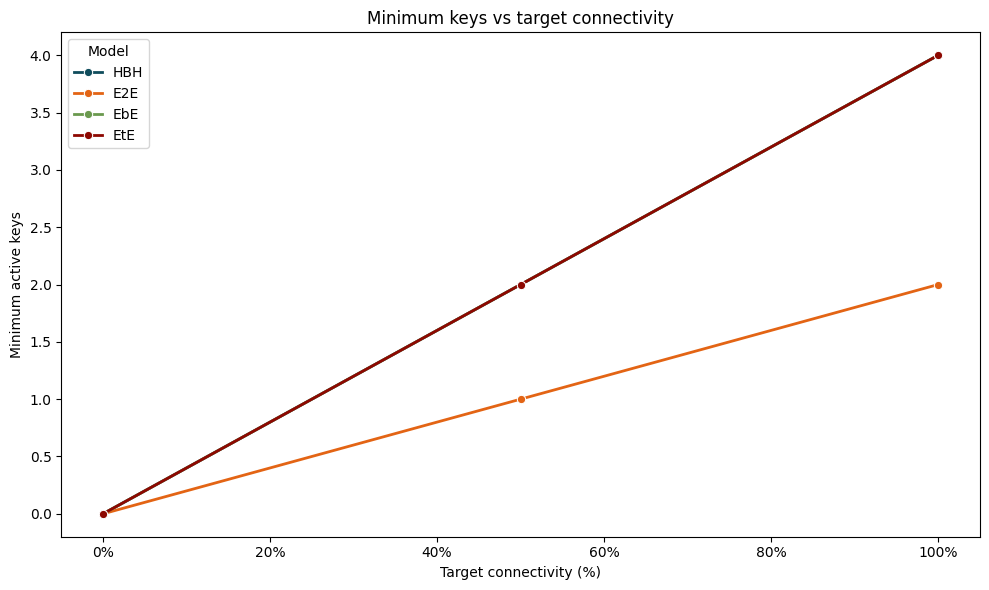

,node,distinct_keys
0,1,2
1,2,2
2,3,2
3,4,2


Largest node inventory: 2


In [10]:
with gp.Env(params={"OutputFlag": 0}) as solver_env:
    policy_frames = [
        model2.solve(
            planner.build(result.protection, policy_id=policy_id),
            target_connectivity_pcts=(0, 50, 100), env=solver_env,
        ).to_frame()
        for policy_id in result.protection.policies
    ]
policy_comparison = pd.concat(policy_frames, ignore_index=True)
model2.plot_selected_keys_vs_connectivity(policy_comparison, normalize_y=False)
plt.tight_layout()
plt.show()

outcome = optimizations["M5"].outcomes[-1]
if outcome.has_solution:
    trace = outcome.trace
    node_inventory = pd.DataFrame([
        {"node": node, "distinct_keys": count}
        for node, count in trace.key_counts_by_node.items()
    ])
    display(node_inventory)
    print(f"Largest node inventory: {trace.max_keys_per_node}")
else:
    print(f"No incumbent; solver status: {outcome.solver_status}")

The trace includes selected routes, pairs, contacts, protection operations,
global keys, and deliveries to every topology node, including nodes with zero
keys. Other plotting helpers show pair coverage, key reuse, contact usage,
gateways, and network crossings. To compare policies, solve one activation
problem per policy and concatenate their `to_frame()` results.

## 5. Handle unreachable pairs

This example retains two requested pairs but removes reverse contacts. Full
coverage is then infeasible. The missing pair stays in the denominator; the
result must not be interpreted as a valid zero-key solution.

In [11]:
one_way_scenario = Scenario(
    topology,
    tuple(contact for contact in contacts if (contact.frm, contact.to) in links),
    pairs=scenario.pairs,
)
one_way_result = pipeline.run(RoutingBatchRequest(one_way_scenario))
one_way_problem = planner.build(one_way_result.protection, policy_id="EDGE_TO_EDGE")
with gp.Env(params={"OutputFlag": 0}) as solver_env:
    coverage_check = model2.solve(
        one_way_problem, target_connectivity_pcts=(50, 100), env=solver_env,
    )
display(coverage_check.to_frame()[[
    "target_connectivity_pct", "required_pairs", "solver_status",
    "has_solution", "selected_keys", "achieved_connectivity_pct",
]])
assert coverage_check.outcomes[0].has_solution
assert not coverage_check.outcomes[1].has_solution
assert coverage_check.outcomes[1].trace is None

,target_connectivity_pct,required_pairs,solver_status,has_solution,selected_keys,achieved_connectivity_pct
0,50.0,1,2,True,2.0,50.0
1,100.0,2,3,False,NaN,NaN


### Add application-specific constraints

Use `build(model, problem)` when you need to add constraints before solving.
The caller then owns both the model and environment. M1/M2/M4 initialize their
sweep constraint at zero; M5 initializes it at full coverage. Set the desired
bound explicitly. M3 declares a fixed full-coverage point.

This example adds a key-storage limit for each node to M5. The initial limits
allow all available scopes; replace the values with your application limits.
Extract numeric values while the model is open. The resulting solution and
trace remain usable after it is closed.

In [12]:
from pipelines.activation import build_trace, extract_solution

node_limits = {node: len(problem.key_scopes) for node in problem.node_ids}
with gp.Env(params={"OutputFlag": 0}) as solver_env:
    with gp.Model("node_storage_limits", env=solver_env) as solver:
        bindings = model5.build(solver, problem)
        bindings.connectivity_constraint.RHS = len(problem.pairs)
        for node, load in bindings.node_delivery.node_key_loads.items():
            solver.addConstr(load <= node_limits[node], name=f"storage_limit[{node}]")
        solver.optimize()
        detached_solution = extract_solution(bindings.activation) if solver.SolCount else None

if detached_solution is not None:
    custom_trace = build_trace(problem, detached_solution)
    print(f"Custom model selected {len(custom_trace.selected_pairs)} pairs")
else:
    print("The custom model has no feasible incumbent.")

Custom model selected 2 pairs


For a new objective, compose `attach_global_activation`, `attach_node_deliveries`,
and `attach_pair_coverage` as needed, then add your budgets and objective.
These components define reusable feasibility constraints and do not choose
an optimization policy. `run_optimization` can execute a custom builder that
returns the `BuiltOptimization` contract: activation bindings plus either a
sweep constraint or an explicit fixed point.

### Try it: change the key assumption without recomputing routes

Repeat M2 with `symmetric_problem` and inspect the number of selected scopes.
Does symmetric normalization change the minimum global-key count? The next
cell provides a runnable comparison. All runs reuse the same routing and
security catalogs.

In [13]:
with gp.Env(params={"OutputFlag": 0}) as solver_env:
    symmetric_optimization = model2.solve(
        symmetric_problem, target_connectivity_pcts=(100,), env=solver_env,
    )
key_mode_comparison = pd.concat([
    optimizations["M2"].to_frame().query("target_connectivity_pct == 100").assign(key_mode="directional"),
    symmetric_optimization.to_frame().assign(key_mode="symmetric"),
], ignore_index=True)
display(key_mode_comparison[["key_mode", "total_key_scopes", "selected_keys", "selected_pairs"]])

,key_mode,total_key_scopes,selected_keys,selected_pairs
0,directional,6,4,2
1,symmetric,5,3,2


## 6. Run the existing scenarios

- [Basic](../scenarios/basic/resultados.ipynb) explores routing, inventories, and
  the first three optimization models. Only 66 of its 132 ordered pairs are
  reachable, so coverage above 50 % is infeasible.
- [Four Planes](../scenarios/wisee_four_planes_polar/four_planes.ipynb) contains
  the full connectivity sweeps, key-share plots, operation-density analysis,
  exposure analysis, and tradeoff figures.

For a full Four Planes analysis, use its linked notebook. To apply the basic
workflow to another dataset, pass the loaded scenario to `RoutingBatchRequest`,
then rebuild the routing, annotation, protection, and activation artifacts before
solving. The one-way example in this guide is specific to the four-node teaching
network and should remain unchanged.

From the repository root, validate all three notebooks in clean kernels:

```bash
python scripts/validate_notebooks.py --output-dir /tmp/bpsec-notebooks
```

Run only this guide and save refreshed outputs:

```bash
python scripts/validate_notebooks.py --notebook docs/pipeline_usage.ipynb \
  --output-dir /tmp/bpsec-guide --write
```

The validator exports executed notebooks, tables, and displayed figures.
`--compare-dir` compares tables with a previous export, excluding run time,
and exits with a nonzero status on differences. Equal objective values do not
always imply identical selected routes because a model may have tied optima.
Use `python -m unittest discover -s tests -v` to run the code tests.

Common mistakes to avoid:

- Passing mutable CGR contacts to a `Scenario`: convert each with
  `ContactSnapshot.from_contact` or use `Scenario.from_files`.
- Treating a route's display label as a globally stable ID: use its typed
  reference inside the catalog that produced it.
- Requesting full coverage without checking unreachable pairs: inspect
  `routes_by_pair` and the returned solver status.
- Reading live Gurobi variables after disposing their model: extract a numeric
  `ActivationSolution` first.
- Mixing notebooks and dependencies from different Python environments:
  select the kernel where `requirements-notebooks.txt` was installed.